In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data import DataLoader

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [3]:
IMAGE_SIZE = 64

LATENT_DIM = 100

BATCH_SIZE = 16

EPOCHS = 50

LR = 0.0002

In [4]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

train_dataset = ImageFolder(
    root="/home/saidul/Desktop/4-2/Deep Learning/data/5_celebrity_faces/train",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Images:", len(train_dataset))

Images: 93


In [5]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(
                100,
                512,
                4,
                1,
                0,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512,
                256,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                3,
                4,
                2,
                1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self,x):
        return self.main(x)

In [6]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                4,
                2,
                1,
                bias=False
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                256,
                512,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                512,
                1,
                4,
                1,
                0,
                bias=False
            ),

            nn.Sigmoid()
        )

    def forward(self,x):
        return self.main(x).view(-1)

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerG = torch.optim.Adam(
    G.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

optimizerD = torch.optim.Adam(
    D.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

In [8]:
g_losses = []
d_losses = []

for epoch in range(EPOCHS):

    for real,_ in train_loader:

        real = real.to(device)

        batch_size = real.size(0)

        real_label = torch.ones(batch_size).to(device)
        fake_label = torch.zeros(batch_size).to(device)

        #####################
        # Train D
        #####################

        optimizerD.zero_grad()

        output_real = D(real)

        loss_real = criterion(
            output_real,
            real_label
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=device
        )

        fake = G(noise)

        output_fake = D(
            fake.detach()
        )

        loss_fake = criterion(
            output_fake,
            fake_label
        )

        lossD = loss_real + loss_fake

        lossD.backward()

        optimizerD.step()

        #####################
        # Train G
        #####################

        optimizerG.zero_grad()

        output = D(fake)

        lossG = criterion(
            output,
            real_label
        )

        lossG.backward()

        optimizerG.step()

    g_losses.append(lossG.item())
    d_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D={lossD.item():.4f} "
        f"G={lossG.item():.4f}"
    )

Epoch [1/50] D=0.6316 G=4.8892
Epoch [2/50] D=0.2776 G=6.6327
Epoch [3/50] D=0.1924 G=8.5002
Epoch [4/50] D=0.3260 G=14.1707
Epoch [5/50] D=0.2207 G=13.9345
Epoch [6/50] D=0.0732 G=13.8983
Epoch [7/50] D=0.0973 G=15.1826
Epoch [8/50] D=0.6526 G=16.6873
Epoch [9/50] D=1.6940 G=14.8416
Epoch [10/50] D=0.0472 G=10.1445
Epoch [11/50] D=0.1090 G=14.5074
Epoch [12/50] D=0.2142 G=9.4512
Epoch [13/50] D=0.9487 G=15.5335
Epoch [14/50] D=0.0785 G=4.8167
Epoch [15/50] D=0.0260 G=12.0940
Epoch [16/50] D=0.0542 G=14.2007
Epoch [17/50] D=0.1536 G=7.4331
Epoch [18/50] D=0.1175 G=5.8200
Epoch [19/50] D=0.2039 G=14.9305
Epoch [20/50] D=0.0593 G=7.3379
Epoch [21/50] D=0.3371 G=7.0910
Epoch [22/50] D=0.2138 G=8.1163
Epoch [23/50] D=1.8118 G=6.8640
Epoch [24/50] D=1.8268 G=3.5953
Epoch [25/50] D=0.5239 G=4.3890
Epoch [26/50] D=0.5315 G=2.9501
Epoch [27/50] D=1.0529 G=1.4096
Epoch [28/50] D=0.3410 G=2.9700
Epoch [29/50] D=0.8872 G=1.1904
Epoch [30/50] D=0.4847 G=4.4516
Epoch [31/50] D=0.4090 G=3.7937
Epoch

In [9]:
g_losses = []
d_losses = []

for epoch in range(EPOCHS):

    for real,_ in train_loader:

        real = real.to(device)

        batch_size = real.size(0)

        real_label = torch.ones(batch_size).to(device)
        fake_label = torch.zeros(batch_size).to(device)

        #####################
        # Train D
        #####################

        optimizerD.zero_grad()

        output_real = D(real)

        loss_real = criterion(
            output_real,
            real_label
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=device
        )

        fake = G(noise)

        output_fake = D(
            fake.detach()
        )

        loss_fake = criterion(
            output_fake,
            fake_label
        )

        lossD = loss_real + loss_fake

        lossD.backward()

        optimizerD.step()

        #####################
        # Train G
        #####################

        optimizerG.zero_grad()

        output = D(fake)

        lossG = criterion(
            output,
            real_label
        )

        lossG.backward()

        optimizerG.step()

    g_losses.append(lossG.item())
    d_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D={lossD.item():.4f} "
        f"G={lossG.item():.4f}"
    )

Epoch [1/50] D=0.6175 G=1.8227
Epoch [2/50] D=0.3608 G=3.3615
Epoch [3/50] D=0.2217 G=4.2027
Epoch [4/50] D=0.3399 G=4.0434
Epoch [5/50] D=0.2147 G=4.9785
Epoch [6/50] D=0.4831 G=8.4362
Epoch [7/50] D=0.3652 G=7.7519
Epoch [8/50] D=0.2097 G=6.9880
Epoch [9/50] D=0.1150 G=5.3785
Epoch [10/50] D=0.1518 G=6.8583
Epoch [11/50] D=0.2341 G=7.3191
Epoch [12/50] D=1.0207 G=19.6570
Epoch [13/50] D=0.3853 G=5.1271
Epoch [14/50] D=0.3849 G=3.9916
Epoch [15/50] D=0.2123 G=4.9770
Epoch [16/50] D=0.3984 G=4.0416
Epoch [17/50] D=0.2127 G=5.3624
Epoch [18/50] D=0.3109 G=6.5394
Epoch [19/50] D=0.3626 G=5.4925
Epoch [20/50] D=0.2661 G=3.6520
Epoch [21/50] D=0.1895 G=4.3355
Epoch [22/50] D=0.1750 G=5.4525
Epoch [23/50] D=0.3267 G=6.8646
Epoch [24/50] D=0.2692 G=6.6026
Epoch [25/50] D=0.1543 G=4.4132
Epoch [26/50] D=0.1196 G=5.1558
Epoch [27/50] D=0.2095 G=4.2505
Epoch [28/50] D=0.4393 G=8.3097
Epoch [29/50] D=0.2478 G=3.4762
Epoch [30/50] D=0.2009 G=5.0833
Epoch [31/50] D=0.4556 G=8.5235
Epoch [32/50] D=

In [10]:
G.eval()

with torch.no_grad():

    noise = torch.randn(
        16,
        LATENT_DIM,
        1,
        1,
        device=device
    )

    fake = G(noise).cpu()

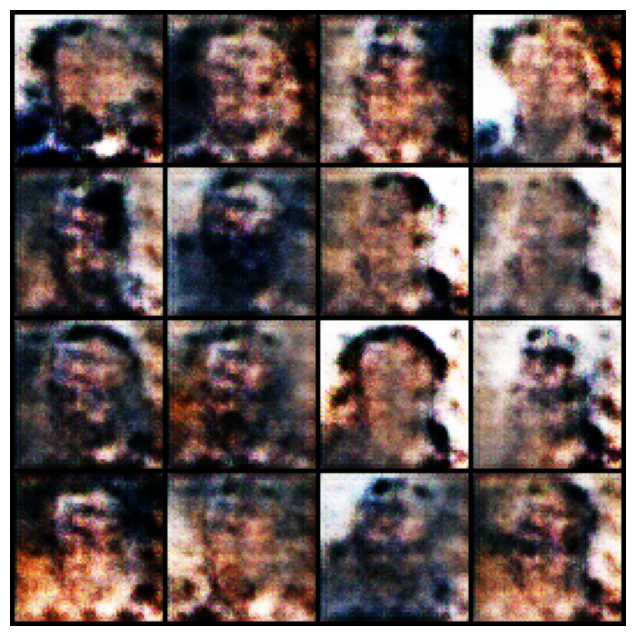

In [11]:
grid = make_grid(
    fake,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.transpose(
        grid.numpy(),
        (1,2,0)
    )
)

plt.axis("off")
plt.show()